# **Reasons Behind Low Customers Ratings (LCR):**

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
data= pd.read_json("data.json")

In [4]:
data.shape

(10999, 12)

In [5]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [6]:
data.head(3)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


> In this analysis, we focus on the `Customer_ratings` and try to improve customer satisfaction.

## **11. Distribution of Customer Ratings:**

In [7]:
data["customer_rating"].head(4)

0    2
1    5
2    2
3    3
Name: customer_rating, dtype: int64

In [8]:
data["customer_rating"].unique()

array([2, 5, 3, 1, 4])

In [11]:
cus_rat= data["customer_rating"].value_counts().reset_index()
cus_rat

,customer_rating,count
0,3,2239
1,1,2235
2,4,2189
3,5,2171
4,2,2165


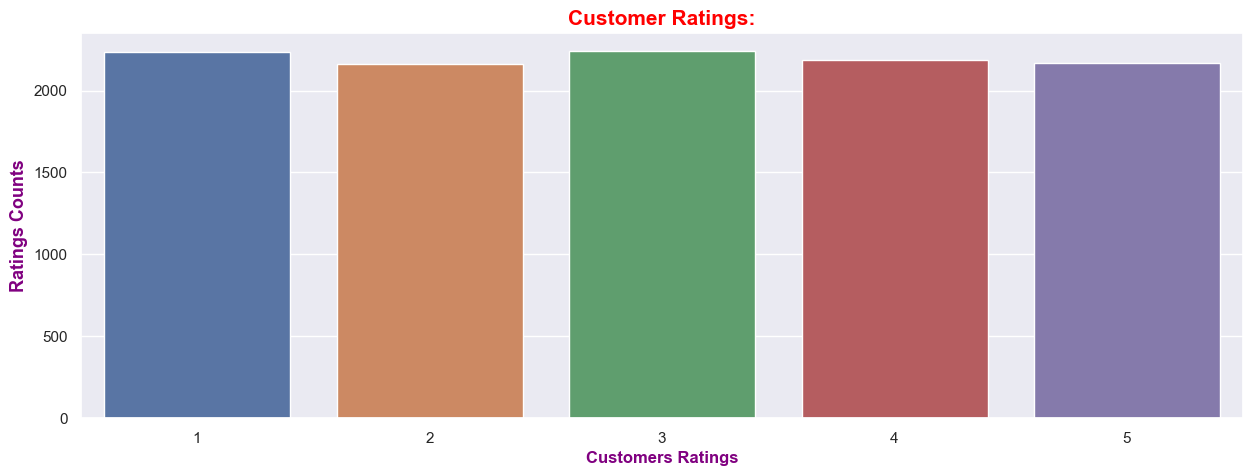

In [18]:
plt.figure(figsize= (15, 5))
sns.set_theme(context= "notebook", style= "darkgrid", palette= "deep")
sns.barplot(data= cus_rat, x= "customer_rating", y= "count", palette= "deep", hue= "customer_rating", legend=False)
plt.title("Customer Ratings:", fontsize= 15, fontweight= "bold", color= "red", loc= "center")
plt.xlabel("Customers Ratings", fontsize= 12, fontweight= "bold", color= "purple")
plt.ylabel("Ratings Counts", fontsize= 13, fontweight= "bold", color= "purple")
plt.show()

SO, there is no high-disbalance in the number of ratings for each rating class. 

---
---
---

## **12. Correlation between Late Deliveries and Ratings:**

In [21]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

To know the linear/ monotonic relation between columns "reached_on_time" and "customer_rating", we can calculate the correlation between them:

In [23]:
data[["reached_on_time", "customer_rating"]].corr(method= "pearson")

,reached_on_time,customer_rating
reached_on_time,1.000000,0.013119
customer_rating,0.013119,1.000000


This shows a very low positive correlation and so there is almost no linear relationship between `reached_on_time` and `customer_rating`.

Since the correlation is close to 0, we can conclude that being "on time" in reaching a customer does not significantly affect their ratings. 

There are various other factors affecting the ratings of products and modeling this relation linearly with `"product on-time delivery"` don't clearly explain their true dependency and influence.

**Check if Late Deliveries Affects Customers Ratings:**

In [37]:
late_del= data.groupby(by= "reached_on_time")["customer_rating"].value_counts(normalize= True).reset_index()
late_del

,reached_on_time,customer_rating,proportion
0,0,1,0.207845
1,0,2,0.201082
2,0,4,0.199729
3,0,3,0.198828
4,0,5,0.192516
5,1,3,0.206765
6,1,5,0.200670
7,1,1,0.200061
8,1,4,0.198537
9,1,2,0.193966


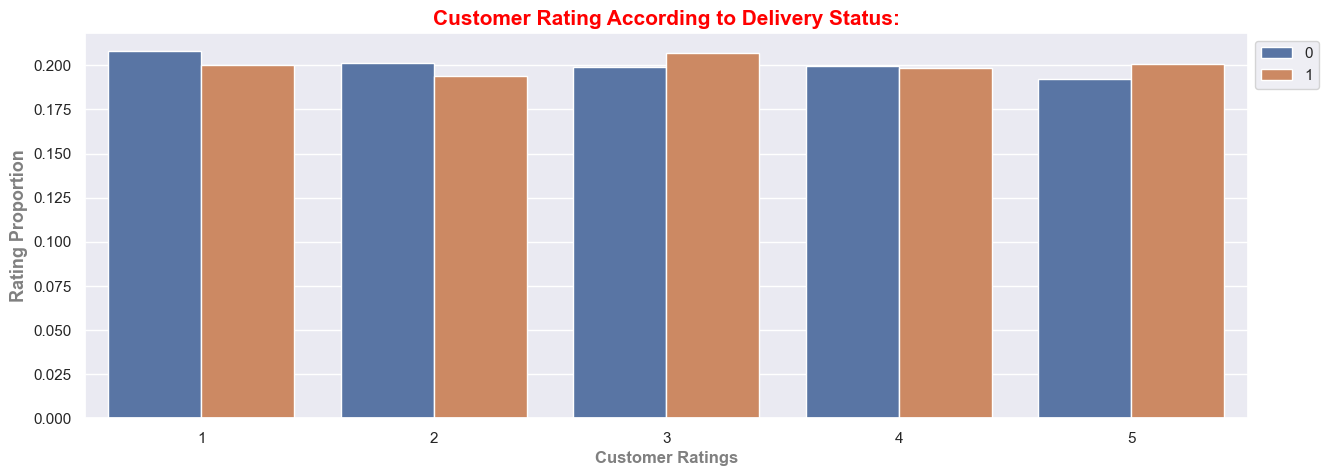

In [38]:
plt.figure(figsize= (15, 5))
sns.barplot(data= late_del, x= "customer_rating", y= "proportion", hue= "reached_on_time")
# Plot legend outside the plot to avoide overlapping: 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Customer Rating According to Delivery Status:", color= "red", fontsize= 15, fontweight= "bold")
plt.xlabel("Customer Ratings", color= "gray", fontweight= "bold", fontsize= 12)
plt.ylabel("Rating Proportion", color= "gray", fontsize= 13, fontweight= "bold")
plt.show()

In [39]:
late_dels= data.groupby(by= "reached_on_time")["customer_rating"].mean().reset_index()
late_dels

,reached_on_time,customer_rating
0,0,2.967989
1,1,3.005790


There is no bias in the ratings according to if the product is delivered on time or it is late.

----
---
----

## **13. Impact of Customer Care Calls on Ratings:** 

In [47]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [53]:
data[['customer_care_calls', 'reached_on_time', "customer_rating"]].head()

,customer_care_calls,reached_on_time,customer_rating
0,4,1,2
1,4,1,5
2,2,1,2
3,3,1,3
4,2,1,2


In [54]:
data["customer_care_calls"].unique()

array([4, 2, 3, 5, 6, 7])

In [55]:
data["customer_rating"].unique()

array([2, 5, 3, 1, 4])

In [80]:
sasd= data.groupby(by= "customer_care_calls")["customer_rating"].value_counts().reset_index()
sasd.head(3)

,customer_care_calls,customer_rating,count
0,2,5,136
1,2,1,130
2,2,3,125


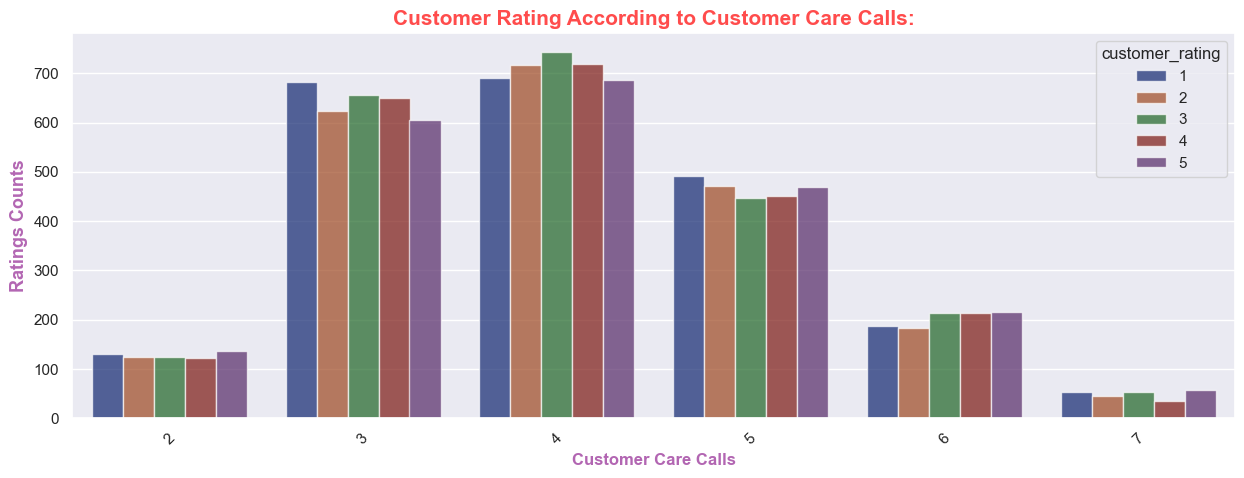

In [73]:
plt.figure(figsize= (15, 5))
sns.barplot(data= sasd, x= "customer_care_calls", y= "count", hue= "customer_rating", palette= "dark", alpha= 0.7)
plt.title("Customer Rating According to Customer Care Calls:", fontsize= 15, fontweight= "bold", color= "red", loc= "center", alpha= 0.7)
plt.xlabel("Customer Care Calls", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.ylabel("Ratings Counts", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
plt.xticks(rotation= 45)
plt.show()

Since, we are interested in the relative behaviors of different number of customer care calls and the corresponding customer ratings, it is more appropriate to use Normalized values for final analysis:

In [79]:
mcp = data.groupby(by= "customer_care_calls")["customer_rating"].value_counts(normalize= True).reset_index()
mcp.head(3)

,customer_care_calls,customer_rating,proportion
0,2,5,0.213166
1,2,1,0.203762
2,2,3,0.195925


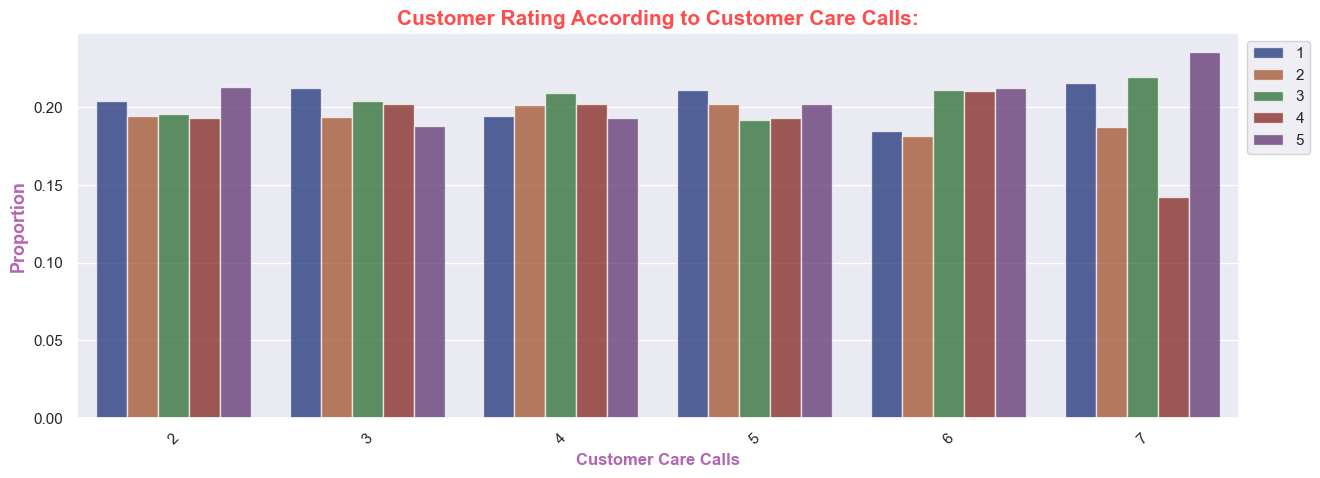

In [77]:
plt.figure(figsize= (15, 5))
sns.barplot(data= mcp, x= "customer_care_calls", y= "proportion", hue= "customer_rating", palette= "dark", alpha= 0.7)
plt.title("Customer Rating According to Customer Care Calls:", fontsize= 15, fontweight= "bold", color= "red", loc= "center", alpha= 0.7)
plt.xlabel("Customer Care Calls", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.ylabel("Proportion", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
plt.xticks(rotation= 45)
# Plot legend outside the plot: 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

Each bar group represents a different number of customer care calls, and within each group, bars represent the proportion of customers giving each rating. 

The data shows no strong trend linking more customer care calls with consistently better or worse ratings. However, for 7 calls, a noticeably higher proportion of customers gave a rating of 5, while a lower proportion gave a rating of 4, potentially indicating that customers who engage more frequently with customer service might end up more satisfied or are more engaged in general. The distribution of ratings appears relatively uniform across other call frequencies, with slight variations.

In [60]:
data.groupby(by= "customer_care_calls")["customer_rating"].mean().reset_index()

,customer_care_calls,customer_rating
0,2,3.017241
1,3,2.959901
2,4,2.998032
3,5,2.972938
4,6,3.083909
5,7,2.995935


----
----
----

## **14. Discounts and Customer Satisfaction:**

In [81]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [82]:
data.head(3)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [ ]:
data["discount_offered"] # This is continuous variable

0        44
1        59
2        48
3        10
4        46
         ..
10994     1
10995     6
10996     4
10997     2
10998     6
Name: discount_offered, Length: 10999, dtype: int64

In [ ]:
data["customer_rating"].unique() # treat them as categorical variables 

array([2, 5, 3, 1, 4])

In [92]:
dsa= data.groupby(by= "customer_rating")["discount_offered"].mean().reset_index()
dsa

,customer_rating,discount_offered
0,1,13.458166
1,2,13.687760
2,3,12.979902
3,4,13.257195
4,5,13.494703


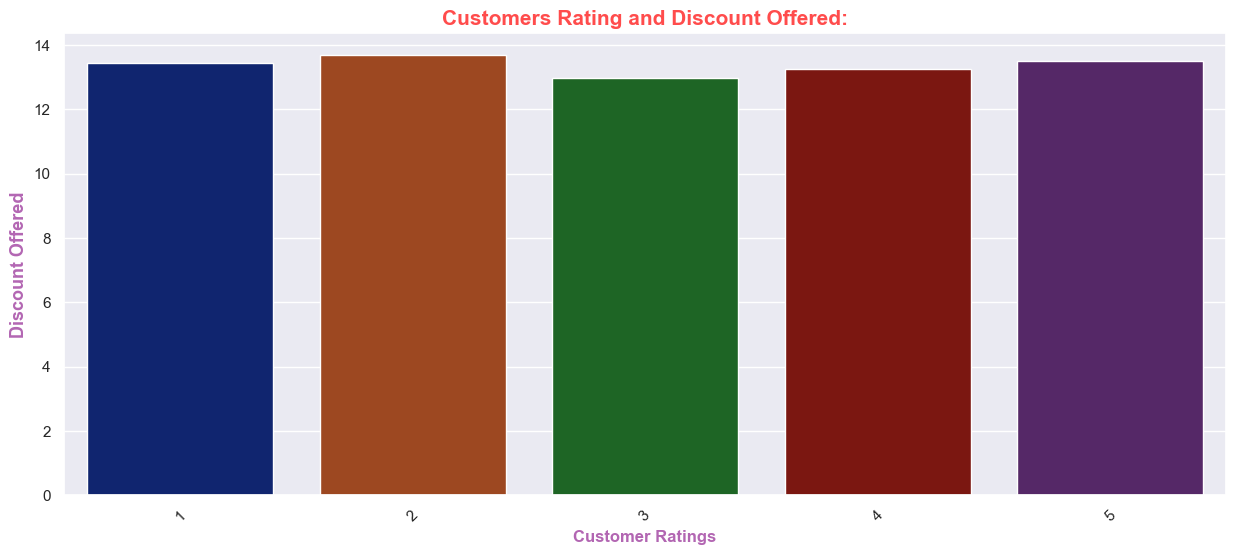

In [97]:
plt.figure(figsize= (15, 6))
sns.set_theme(context= "notebook", style= "darkgrid")
sns.barplot(data= dsa, x= "customer_rating", y= "discount_offered", palette= "dark", hue= "customer_rating", legend= False)
plt.title("Customers Rating and Discount Offered:", color= "red", fontsize= 15, fontweight= "bold", alpha= 0.7)
plt.xlabel("Customer Ratings", color= "purple", fontsize= 12, fontweight= "bold", alpha= 0.6)
plt.ylabel("Discount Offered", color= "purple", fontsize= 13, fontweight= "bold", alpha= 0.6)
plt.xticks(rotation= 45)
plt.show()  

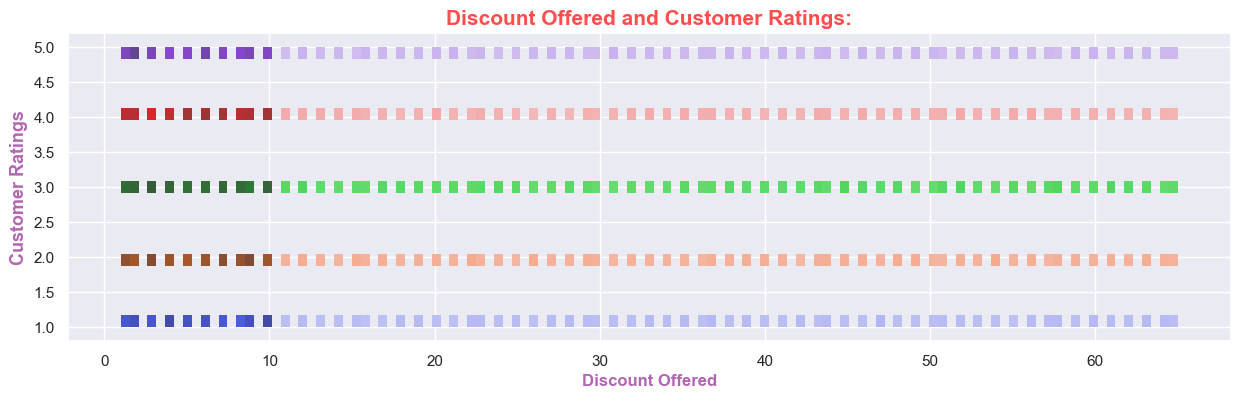

In [110]:
plt.figure(figsize= (15, 4))
sns.histplot(data= data, y= "customer_rating",  x= "discount_offered", palette="bright", hue= "customer_rating", legend= False)
plt.title("Discount Offered and Customer Ratings:", fontsize= 15, fontweight= "bold", color= "red", loc= "center", alpha= 0.7)
plt.xlabel("Discount Offered", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.ylabel("Customer Ratings", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
plt.show()

In [113]:
data[["discount_offered", "customer_rating"]].corr(method= "spearman")

,discount_offered,customer_rating
discount_offered,1.000000,-0.002299
customer_rating,-0.002299,1.000000


A correlation coefficient $r$ of $-0.002299$, is very close to zero indicating very little to no correlation between discount offered and the customer ratings. 

Offering discounts on products didn't seem to have positive effect on customer ratings.

----
---
----

## **15. Product Importance vs. Customer Rating:**  

In [114]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [ ]:
data["product_importance"].unique() #categories

array(['low', 'medium', 'high'], dtype=object)

In [116]:
data["customer_rating"].unique()

array([2, 5, 3, 1, 4])

In [119]:
mean_rating= data.groupby(by= "product_importance")["customer_rating"].mean().reset_index(name= "mean_rating")
mean_rating

,product_importance,mean_rating
0,high,2.993671
1,low,2.983576
2,medium,2.997686


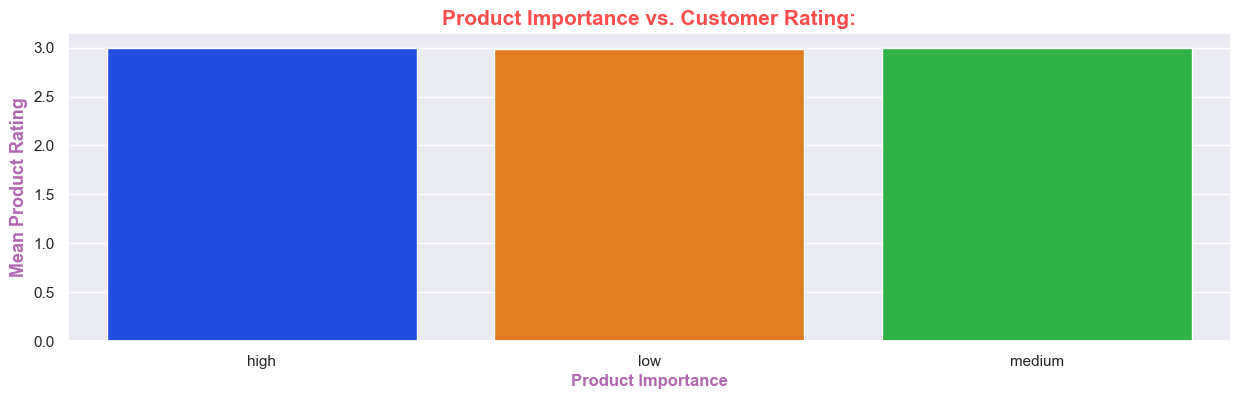

In [123]:
plt.figure(figsize= (15, 4))
sns.barplot(data= mean_rating, y= "mean_rating",  x= "product_importance", palette="bright", hue= "product_importance", legend= False)
plt.title("Product Importance vs. Customer Rating:", fontsize= 15, fontweight= "bold", color= "red", loc= "center", alpha= 0.7)
plt.xlabel("Product Importance", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.ylabel("Mean Product Rating", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
plt.show()

In [131]:
robust_rating= data.groupby(by= "product_importance")["customer_rating"].value_counts(normalize= True).reset_index(name= "mean_rating")
robust_rating.sample(5)

,product_importance,customer_rating,mean_rating
1,high,4,0.203586
14,medium,1,0.196045
7,low,3,0.198981
2,high,1,0.196203
8,low,5,0.198414


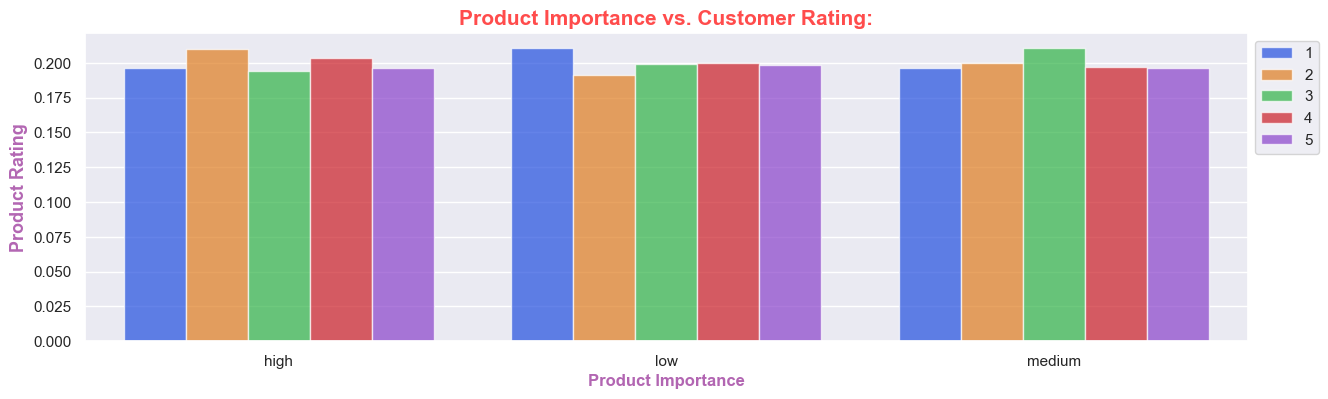

In [130]:
plt.figure(figsize= (15, 4))
sns.barplot(data= robust_rating, y= "mean_rating",  x= "product_importance", palette="bright", hue= "customer_rating", legend= True, alpha= 0.7)
plt.title("Product Importance vs. Customer Rating:", fontsize= 15, fontweight= "bold", color= "red", loc= "center", alpha= 0.7)
plt.xlabel("Product Importance", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.ylabel("Product Rating", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
# plot legend outside the main plot: 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

While giving ratings of the products, customers did not care if the product is of high importance of not. Ratings for all product categories (by importance) are almost identical.

---
---
---

## **16. Prior Purchases and Customer Loyalty/Rating:**

In [132]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [133]:
data[["prior_purchase", "customer_rating"]]

,prior_purchase,customer_rating
0,3,2
1,2,5
2,4,2
3,4,3
4,3,2
...,...,...
10994,5,1
10995,5,1
10996,5,4
10997,6,2


In [147]:
wq= data.groupby(by= "prior_purchase")["customer_rating"].mean().reset_index()
wq.sample(3)

,prior_purchase,customer_rating
7,10,3.196629
2,4,3.029234
5,7,2.867647


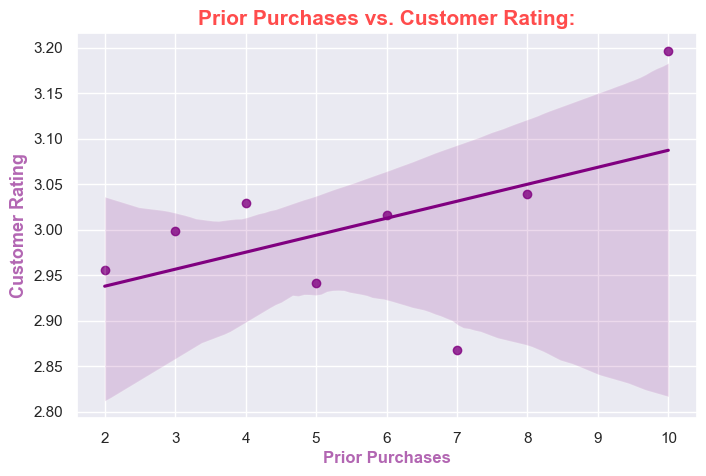

In [155]:
plt.figure(figsize= (8, 5))
#sns.scatterplot(data= wq, x= "prior_purchase", y= "customer_rating")
sns.regplot(data= wq, x= "prior_purchase", y= "customer_rating", color= "purple")
plt.title("Prior Purchases vs. Customer Rating:", fontsize= 15, fontweight= "bold", color= "red", loc= "center", alpha= 0.7)
plt.xlabel("Prior Purchases", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.ylabel("Customer Rating", fontsize= 13, fontweight= "bold", color= "purple", alpha= 0.6)
plt.show()

There seems to have a moderate linear relationship between the prior purchase and the customer ratings. As the total number of prior purchases increases, customer ratings also tends to increase to some extents as shown in the regression plot above. 

In [138]:
data.groupby(by= "prior_purchase")["customer_rating"].value_counts(normalize=True).reset_index()

,prior_purchase,customer_rating,proportion
0,2,1,0.216622
1,2,4,0.200077
2,2,2,0.198153
3,2,5,0.193536
4,2,3,0.191612
5,3,3,0.209608
6,3,2,0.200000
7,3,4,0.198989
8,3,1,0.195954
9,3,5,0.195449


----
---
----

## **17. Weight and Cost Impact on Ratings:** 

Here we check if the value (`cost`) of the product, or difficulty of shipping (`weight`) influences how a customer rates the service.

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
import warnings 
warnings.filterwarnings(action= "ignore")

In [4]:
data= pd.read_json("data.json")
data.shape

(10999, 12)

In [5]:
data.head(4)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
3,4,B,Flight,3,3,176,4,medium,M,10,1177,1


In [5]:
# Check for data types
data.dtypes

id                      int64
warehouse_block        object
mode_of_shipment       object
customer_care_calls     int64
customer_rating         int64
cost_of_product         int64
prior_purchase          int64
product_importance     object
gender                 object
discount_offered        int64
weight_gms              int64
reached_on_time         int64
dtype: object

In [6]:
data[["cost_of_product", "weight_gms"]].head(3)

,cost_of_product,weight_gms
0,177,1233
1,216,3088
2,183,3374


In [7]:
data[["cost_of_product", "weight_gms"]].corr(method= "spearman")

,cost_of_product,weight_gms
cost_of_product,1.00000,-0.13198
weight_gms,-0.13198,1.00000


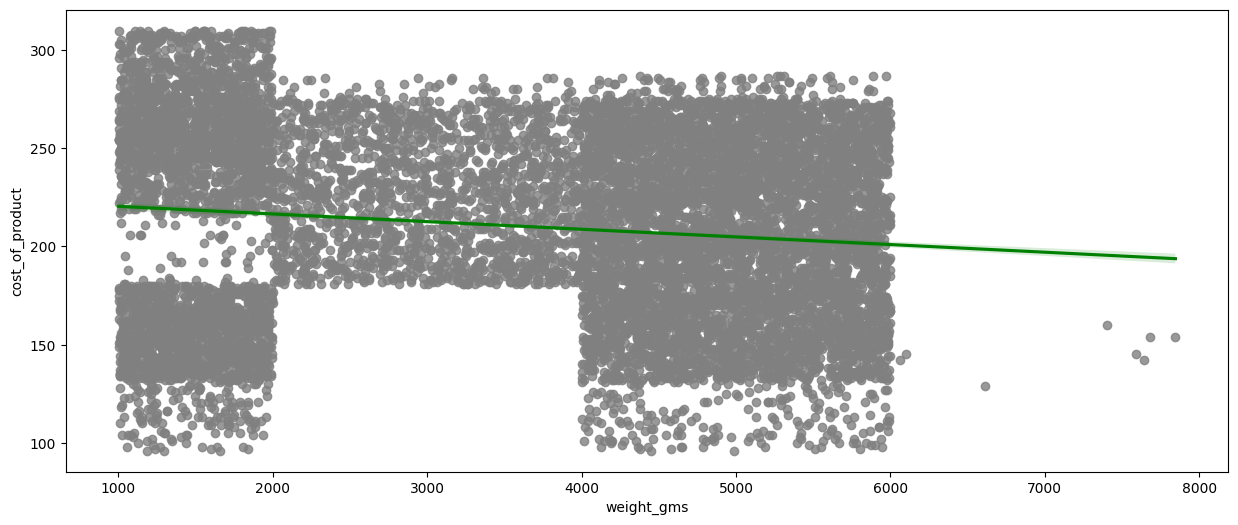

In [8]:
plt.figure(figsize= (15, 6))
sns.regplot(data[["cost_of_product", "weight_gms"]], y= data["cost_of_product"], x= data["weight_gms"], scatter_kws={"color": "gray"}, line_kws={"color": "green"}, )
plt.show()

A slight downtrend was seen but considering the complexity of the relation this is not conclusive and can be thought of as the flat line.

So, the correlation coefficient does shows no relation between them. Lets use different approaches to analyze these things:

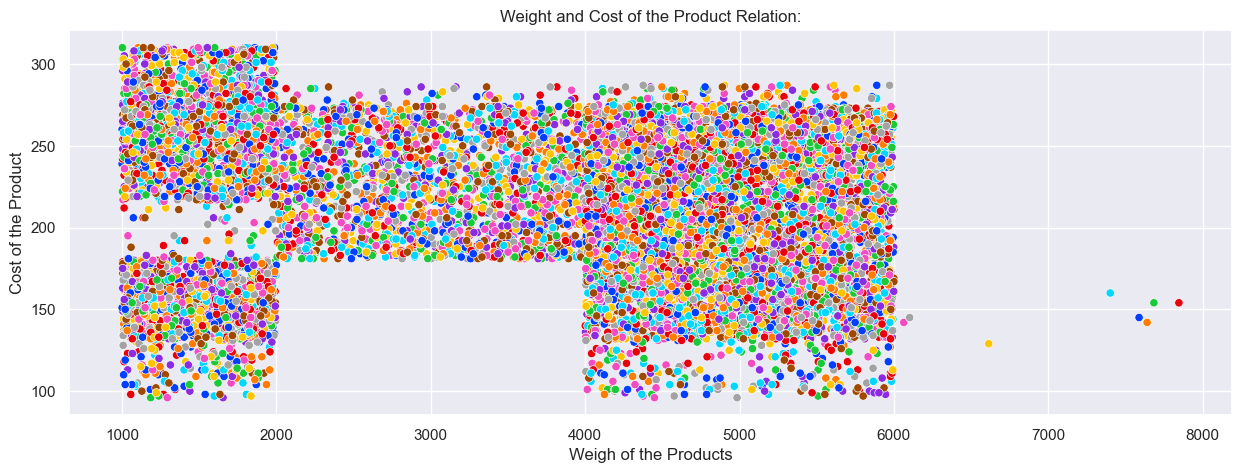

In [9]:
plt.figure(figsize= (15, 5))
sns.set_theme(context= "notebook", style= "darkgrid")
sns.scatterplot(data= data, x= "weight_gms", y= "cost_of_product", palette="bright", hue= "weight_gms", legend=False)
plt.title("Weight and Cost of the Product Relation:")
plt.xlabel("Weigh of the Products")
plt.ylabel("Cost of the Product")
plt.show()

Excluding a gap visible between 2000-to-4000 gms, the plot shows almost no relation between these two variables. 

In [10]:
data.head(3)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


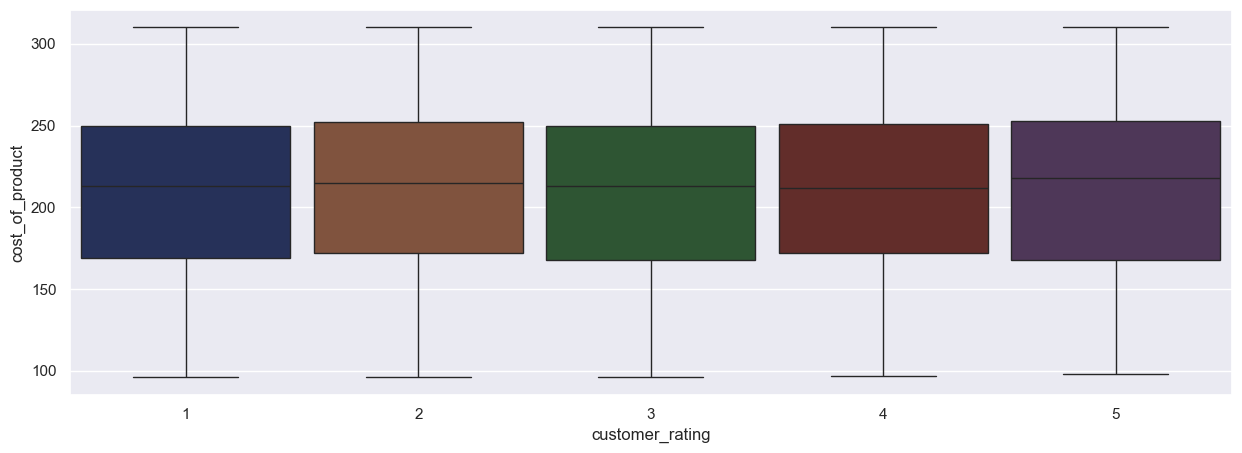

In [11]:
plt.figure(figsize= (15, 5))
sns.set_theme(context= "notebook", style= "darkgrid")
sns.boxplot(data= data, x= "customer_rating", y= "cost_of_product", width= 0.9, palette= "dark", saturation= 0.4)
plt.show()

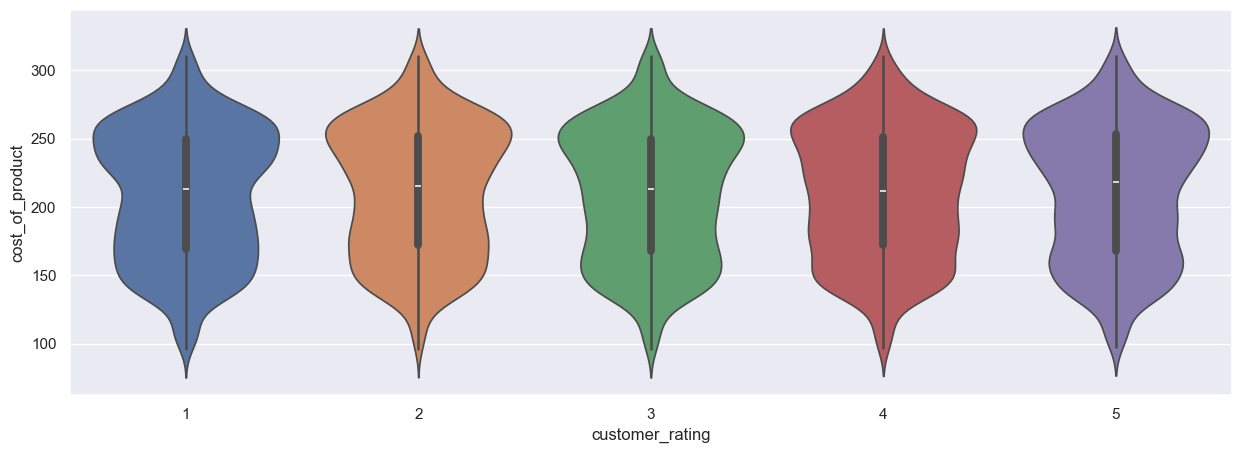

In [12]:
plt.figure(figsize= (15, 5))
sns.set_theme(context= "notebook", style= "darkgrid")
sns.violinplot(data= data, x= "customer_rating", y= "cost_of_product", palette= "deep")
plt.show()

Plot for each of the rating category looks identically same. 

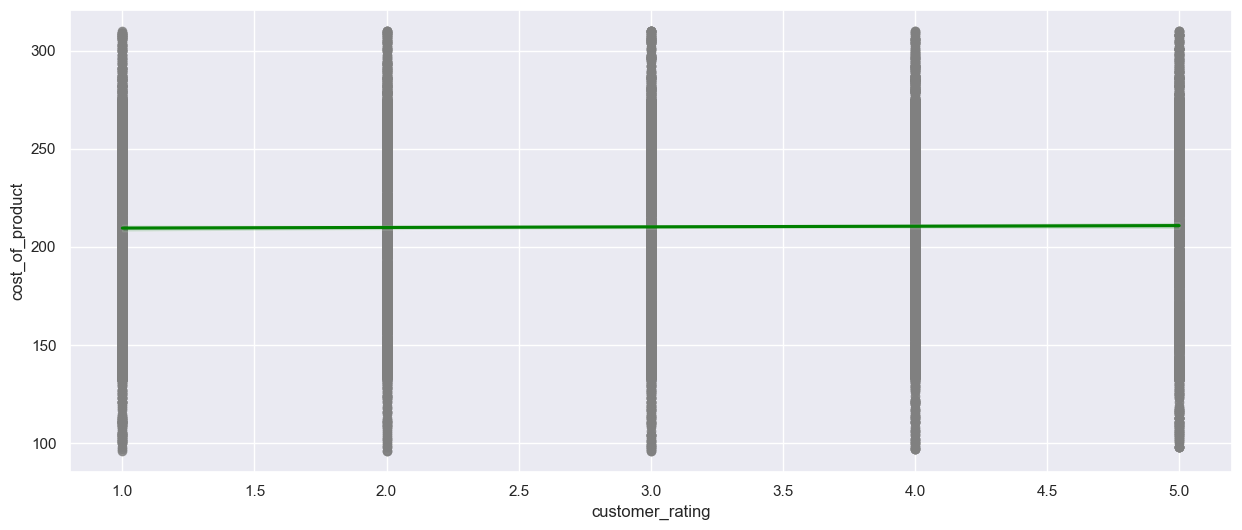

In [13]:
# Not an ideal approach of using regression (assumes linear relation) 
# between categories, but still can be handy for rough estimations: 

plt.figure(figsize= (15, 6))
sns.regplot(data= data, x= "customer_rating", y= "cost_of_product", scatter_kws={"color": "gray"}, line_kws={"color": "green"})
plt.show()

Linearly they are not related as shown by flat line under linear assumptions.

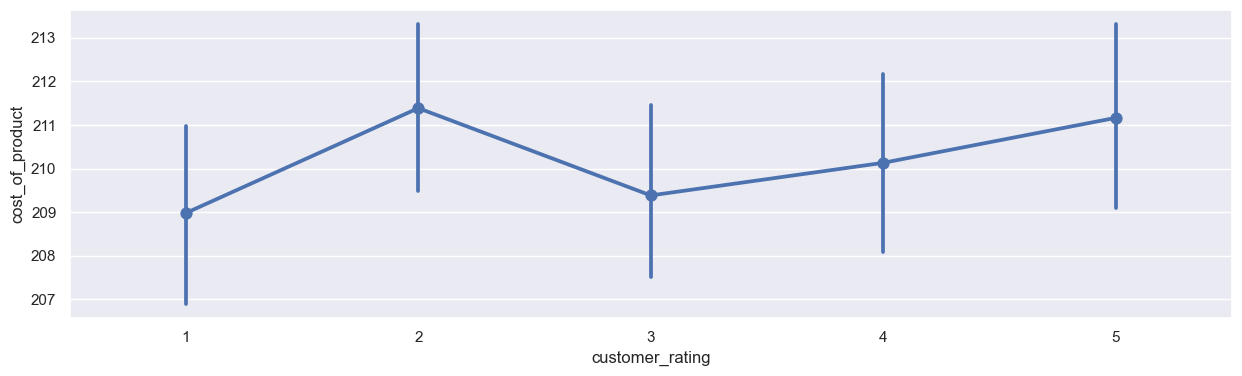

In [14]:
# Point plot: 
plt.figure(figsize= (15, 4))
sns.pointplot(data=data, x="customer_rating", y="cost_of_product")
plt.show()

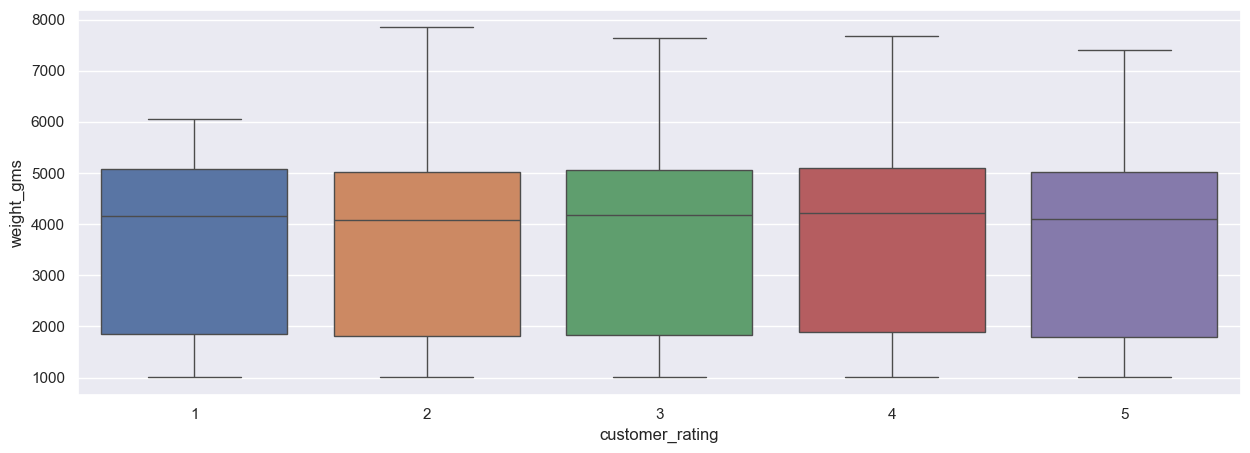

In [15]:
plt.figure(figsize= (15, 5))
sns.set_theme(context= "notebook", style= "darkgrid")
sns.boxplot(data= data, x= "customer_rating", y= "weight_gms", palette= "deep")
plt.show()

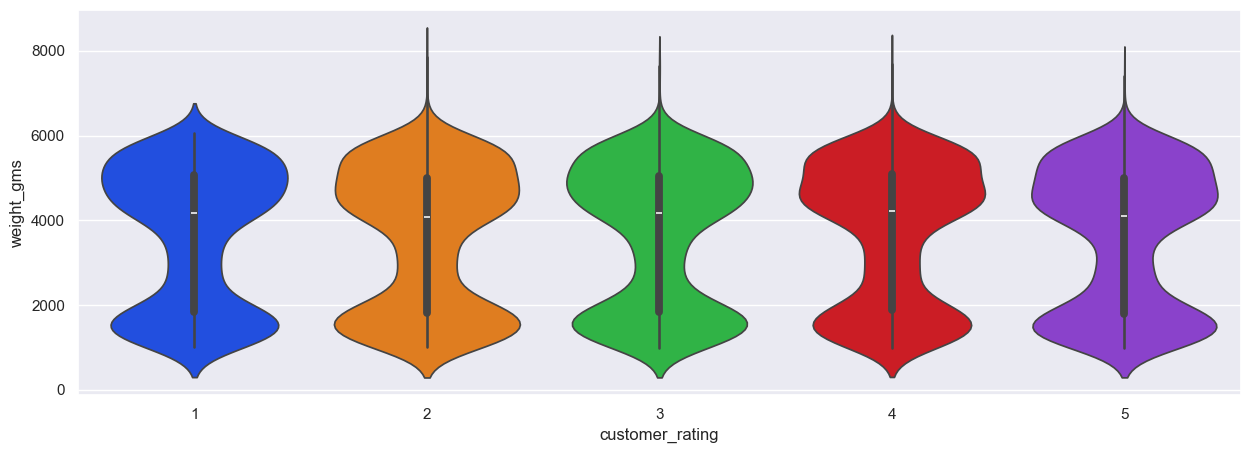

In [16]:
plt.figure(figsize= (15, 5))
sns.set_theme(context= "notebook", style= "darkgrid")
sns.violinplot(data= data, x= "customer_rating", y= "weight_gms", palette= "bright")
plt.show()

Plots for each of the customer rating class are almost identical. `Customer Review` distribution for each rating category (eg. 1 or, 2, etc.) exhibits bimodal characterstics having narrow channed from weights: 2000 to 4000 grams. No signs of relation between variables was observed.

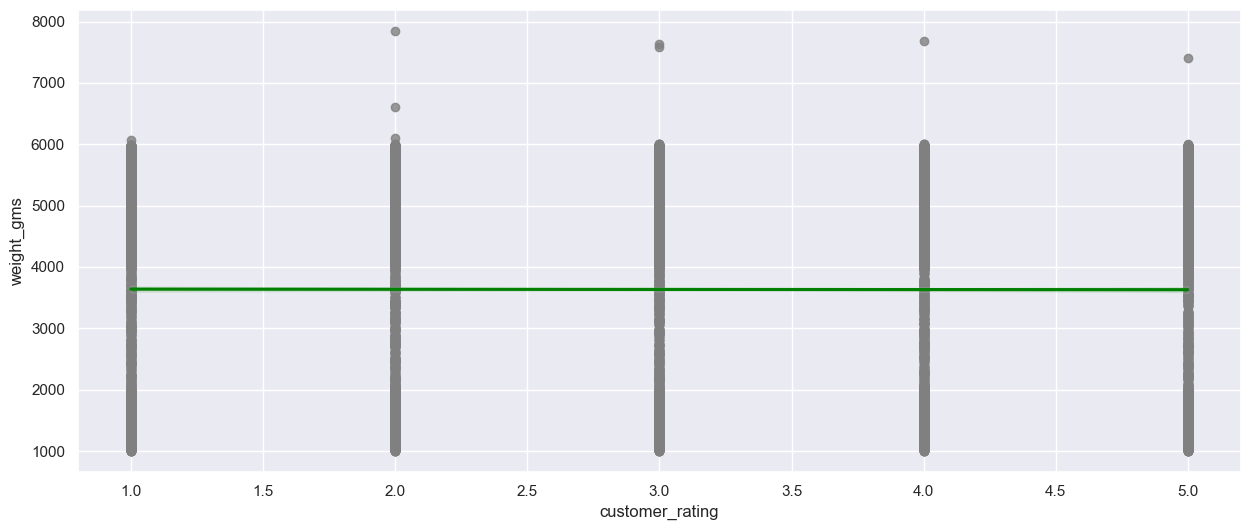

In [17]:
# Using Categorical data for analysis but still if a specific category dominates then, 
# our line will behave accordingly and can be effective in analyzing the dependency.

plt.figure(figsize= (15, 6))
sns.regplot(data= data, x= "customer_rating", y= "weight_gms", scatter_kws={"color": "gray"}, line_kws={"color": "green"})
plt.show()

Flat line, and hence, considering other variables constant, customer ratings and weight of the product did not seems to have any relation at all. 

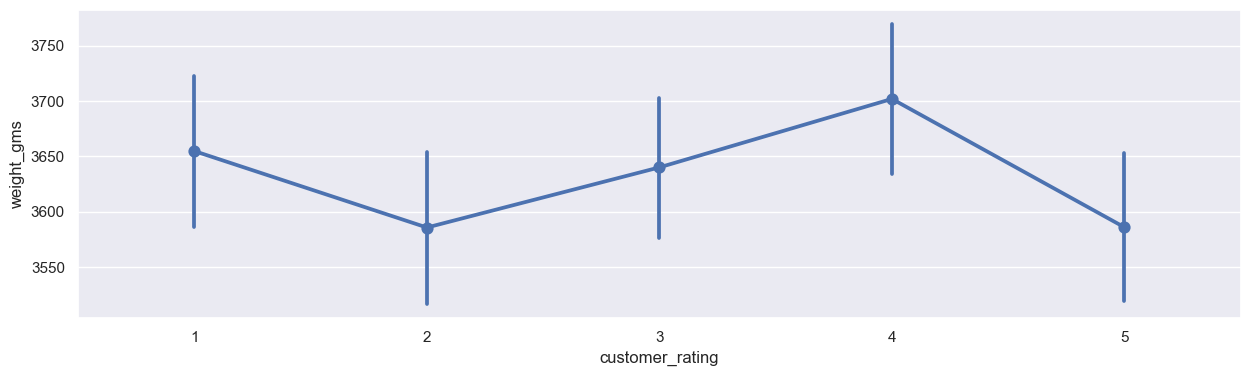

In [18]:
# Point plot: 
plt.figure(figsize= (15, 4))
sns.pointplot(data=data, x="customer_rating", y="weight_gms")
plt.show()

All these points to one conclusin that the customer reviews were not influenced by the weight of the products or the cost of the products either. Customer did not care if the shipping difficulty is high or the product is of high importance. 

---
---
----
----

## **18. Interaction Effect: Delays and Customer Calls:**

* **Description:** Analyze if the combination of a late delivery *and* multiple calls has a disproportionately negative effect on ratings.

* **How to do it in Python:** Create a new categorical column that combines status (e.g., 'On-Time, Low Calls', 'Late, Low Calls', 'Late, High Calls'). Then, use `groupby()` on this new column to see the average `Customer_rating` for each combined scenario.

**1. First, analyze if the customer care calls are due to the late deliveries or not:**

In [4]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [66]:
data.head(2)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1


In [19]:
customer_late= data[["customer_care_calls", "reached_on_time"]]
customer_late.head(3)

,customer_care_calls,reached_on_time
0,4,1
1,4,1
2,2,1


In [6]:
customer_late.dtypes

customer_care_calls    int64
reached_on_time        int64
dtype: object

Despite being numeric data, both of these variables are categorical.

In [20]:
pla= customer_late.groupby(by= "customer_care_calls")["reached_on_time"].value_counts(normalize=True).reset_index()
pla

,customer_care_calls,reached_on_time,proportion
0,2,1,0.652038
1,2,0,0.347962
2,3,1,0.625117
3,3,0,0.374883
4,4,1,0.597695
5,4,0,0.402305
6,5,1,0.584192
7,5,0,0.415808
8,6,1,0.516288
9,6,0,0.483712


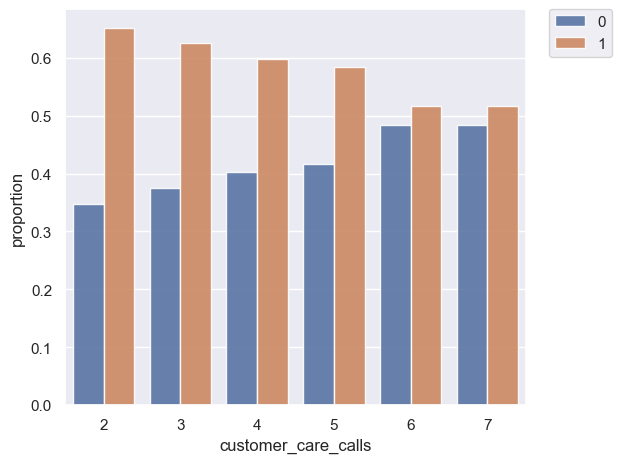

In [22]:
sns.barplot(data=pla, x="customer_care_calls", y="proportion", hue="reached_on_time", alpha=0.9)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()  # Optional: Adjusts plot to make room for the legend
plt.show()

So, as the customer care calls made by customers increases, the proportion of deliveries not reaching on time as increases as indicated by the increasing heights of the blue bars.

In [23]:
data.head(3)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


In [28]:
# Define what counts as "Low" and "High" calls:
call_threshold = data['customer_care_calls'].median()

def status_combiner(row):
    if row['reached_on_time'] == 1:
        time_status = 'On-Time'
    else:
        time_status = 'Late'
    call_status = 'Low Calls' if row['customer_care_calls'] <= call_threshold else 'High Calls'
    return f"{time_status}, {call_status}"

# Create the new categorical column
data['status'] = data.apply(status_combiner, axis=1)
data.head(2)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time,status
0,1,D,Flight,4,2,177,3,low,F,44,1233,1,"On-Time, Low Calls"
1,2,F,Flight,4,5,216,2,low,M,59,3088,1,"On-Time, Low Calls"


In [29]:
# Group by the new `status column` and calculate average customer rating
status_avg_rating = data.groupby('status')['customer_rating'].mean().reset_index()
status_avg_rating

,status,customer_rating
0,"Late, High Calls",2.961319
1,"Late, Low Calls",2.971668
2,"On-Time, High Calls",3.040796
3,"On-Time, Low Calls",2.990336


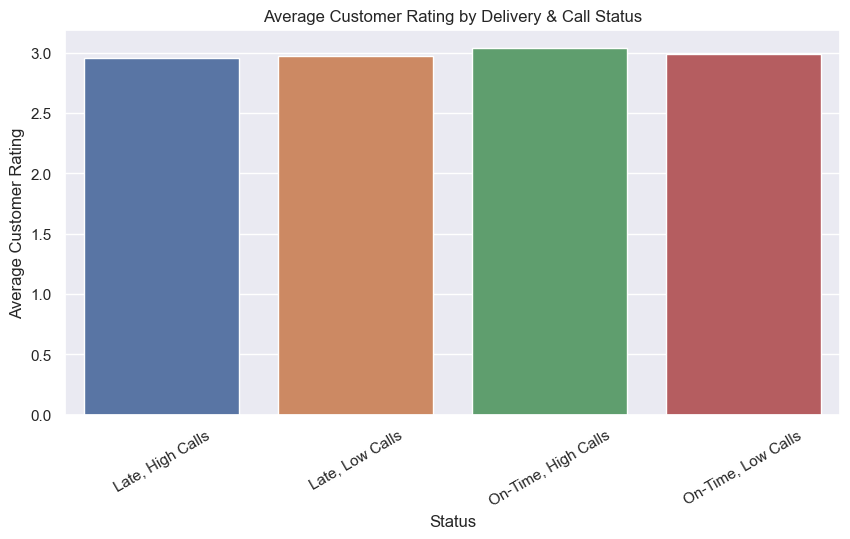

In [26]:
plt.figure(figsize=(10,5))
sns.barplot(data=status_avg_rating, x='status', y='customer_rating', palette='deep')
plt.title('Average Customer Rating by Delivery & Call Status')
plt.xlabel('Status')
plt.ylabel('Average Customer Rating')
plt.xticks(rotation=30)
plt.show()

The combination of late deliveries and multiple calls hvve no disproportionately negative effect on ratings as the average customer ratings for each combination of status were roughly equal. 

---
----
----
----
-----

## **19. Unhappy Customer Segmentation:**

In [56]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [ ]:
data= data.drop(columns= ["status"], axis= 1)

In [57]:
data.head(2)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1


All the customers who gave the minimum rankings ie. either 1 or 2 for the products:

In [58]:
low_rank_cum= data[(data["customer_rating"] == 1) | (data["customer_rating"] == 2)]
low_rank_cum.head(3)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [59]:
# OR, 

low_rank_cum= data[data["customer_rating"].isin([1, 2])]

In [60]:
low_rank_cum.shape

(4400, 12)

In [61]:
low_rank_cum.sample(3)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
3889,3890,F,Ship,3,1,202,2,medium,F,7,4506,1
1651,1652,F,Flight,4,1,167,3,low,F,57,1782,1
4841,4842,F,Ship,5,1,156,6,medium,F,4,4821,0


In [63]:
low_rank_cum["mode_of_shipment"].value_counts().reset_index(name= "count")

,mode_of_shipment,count
0,Ship,2961
1,Flight,731
2,Road,708


In [64]:
low_rank_cum["mode_of_shipment"].value_counts(normalize= True).reset_index(name= "count")

,mode_of_shipment,count
0,Ship,0.672955
1,Flight,0.166136
2,Road,0.160909


Here, for the products which got low ranking (1 or 2), majority of shipments (more then 67%) were delivered through Ocean. 

In [65]:
low_rank_cum["product_importance"].value_counts(normalize= True).reset_index(name= "count")

,product_importance,count
0,low,0.484545
1,medium,0.427955
2,high,0.087500


Half of the low ranking products are actually from low product importance category. This is very important finding. Even more interesting finding is that only 10% of such products were categorized as high importance products. 

SO, majority of low ranking products were actually belongs to mid-to-low importance catogories. 

In [68]:
low_rank_cum["warehouse_block"].value_counts(normalize= False).reset_index(name= "count")

,warehouse_block,count
0,F,1453
1,A,770
2,B,747
3,C,726
4,D,704


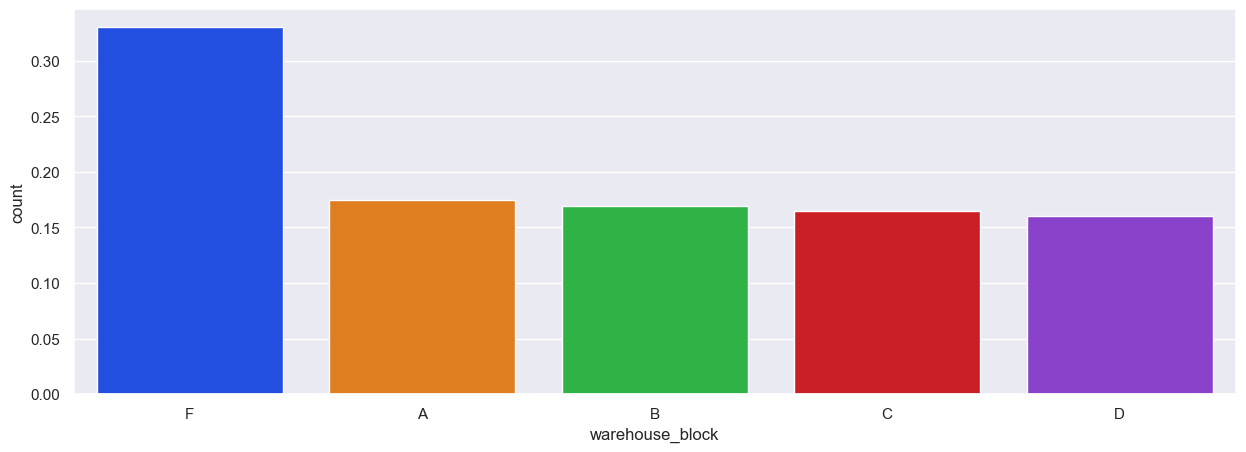

In [72]:
plt.figure(figsize= (15, 5))
sns.set_theme(context= "notebook", style= "darkgrid")
sns.barplot(x= low_rank_cum["warehouse_block"].value_counts(normalize= True).reset_index(name= "count")["warehouse_block"], y= low_rank_cum["warehouse_block"].value_counts(normalize= True).reset_index(name= "count")["count"], palette= "bright")
plt.show()

Warehouse F stands out among all other warehouses indicating that this warehouse is contributing significantly in low ranking. There is something definitely going within this warehouse causing a large portion of deliveries from warehouse F have very low ratings.

In [17]:
low_rank_cum.head(3)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1
4,5,C,Flight,2,2,184,3,medium,F,46,2484,1


In [18]:
low_rank_cum.groupby(by= "mode_of_shipment")["product_importance"].value_counts(normalize= True).reset_index(name= "count")

,mode_of_shipment,product_importance,count
0,Flight,low,0.461012
1,Flight,medium,0.451436
2,Flight,high,0.087551
3,Road,low,0.519774
4,Road,medium,0.391243
5,Road,high,0.088983
6,Ship,low,0.481932
7,Ship,medium,0.430935
8,Ship,high,0.087133


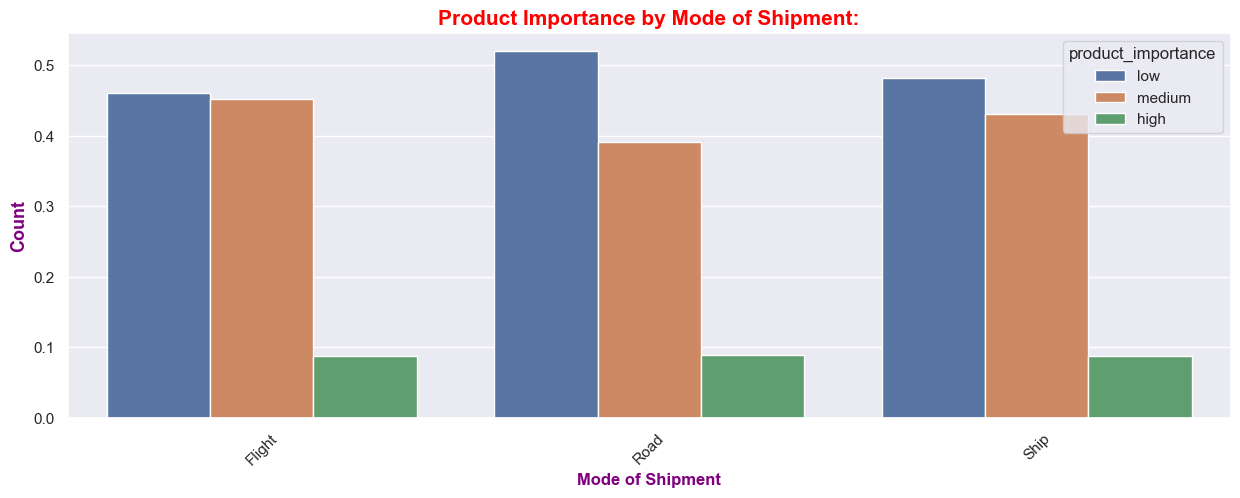

In [19]:
plt.figure(figsize= (15, 5))
sns.set_theme(context= "notebook", style= "darkgrid")
sns.barplot(x= low_rank_cum.groupby(by= "mode_of_shipment")["product_importance"].value_counts(normalize= True).reset_index(name= "count")["mode_of_shipment"], y= low_rank_cum.groupby(by= "mode_of_shipment")["product_importance"].value_counts(normalize= True).reset_index(name= "count")["count"], 
hue= low_rank_cum.groupby(by= "mode_of_shipment")["product_importance"].value_counts(normalize= True).reset_index(name= "count")["product_importance"])
plt.title("Product Importance by Mode of Shipment:", fontsize= 15, fontweight= "bold", color= "red", loc= "center")
plt.xlabel("Mode of Shipment", fontsize= 12, fontweight= "bold", color= "purple")
plt.ylabel("Count", fontsize= 13, fontweight= "bold", color= "purple")
plt.xticks(rotation= 45)
plt.show()

Shipping is not optimizes according to the product importance. All or majority of high-importance products should be air delivered (but this not seen from above plot). Majority of medium-importance products should be shipped via roads and other products should be delivered via ocean. This un-efficient approach might be the contributer of poor customer ratings for these products. 

In [50]:
aa= low_rank_cum.groupby(by= "mode_of_shipment")["warehouse_block"].value_counts(normalize= True).reset_index(name= "count")
aa.head(3)

,mode_of_shipment,warehouse_block,count
0,Flight,F,0.320109
1,Flight,D,0.183311
2,Flight,C,0.166895


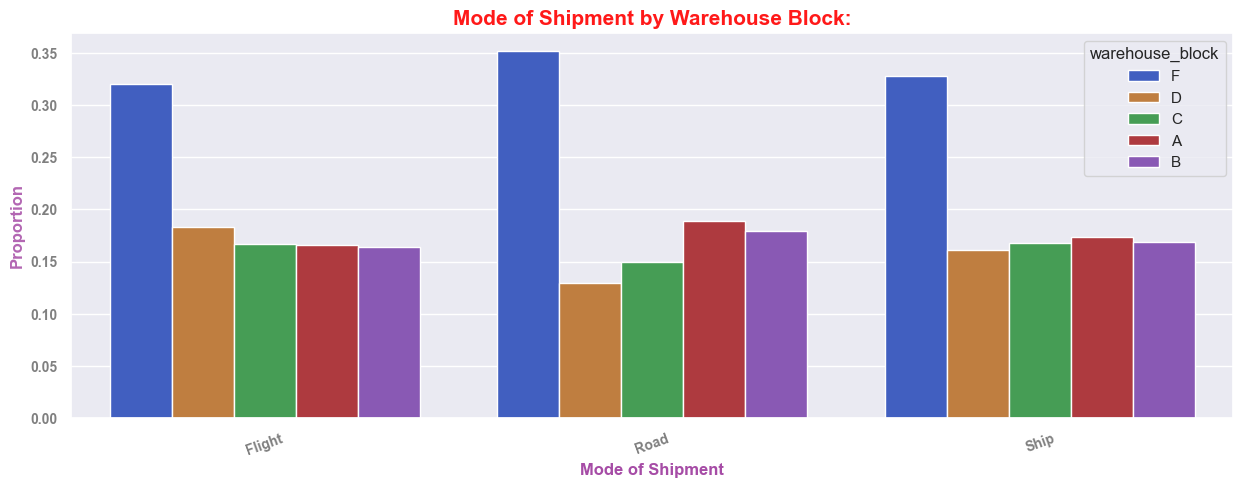

In [53]:
plt.figure(figsize= (15, 5))
sns.set_theme(context= "notebook", style= "darkgrid",)
sns.barplot(data= aa, x= "mode_of_shipment", y= "count", hue= "warehouse_block", palette= "bright", saturation= 0.5) 
plt.title("Mode of Shipment by Warehouse Block:", fontsize= 15, fontweight= "bold", color= "red", alpha= 0.9)
plt.xlabel("Mode of Shipment", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.ylabel("Proportion", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.xticks(rotation= 20, fontsize= 10, fontweight= "bold", color= "gray", alpha= 1.0)
plt.yticks(fontsize= 10, fontweight= "bold", color= "gray")
plt.show()

In [43]:
aa= low_rank_cum.groupby(by= "product_importance")["warehouse_block"].value_counts(normalize= True).reset_index(name= "count")
aa.head(3)

,product_importance,warehouse_block,count
0,high,F,0.348052
1,high,C,0.181818
2,high,A,0.166234


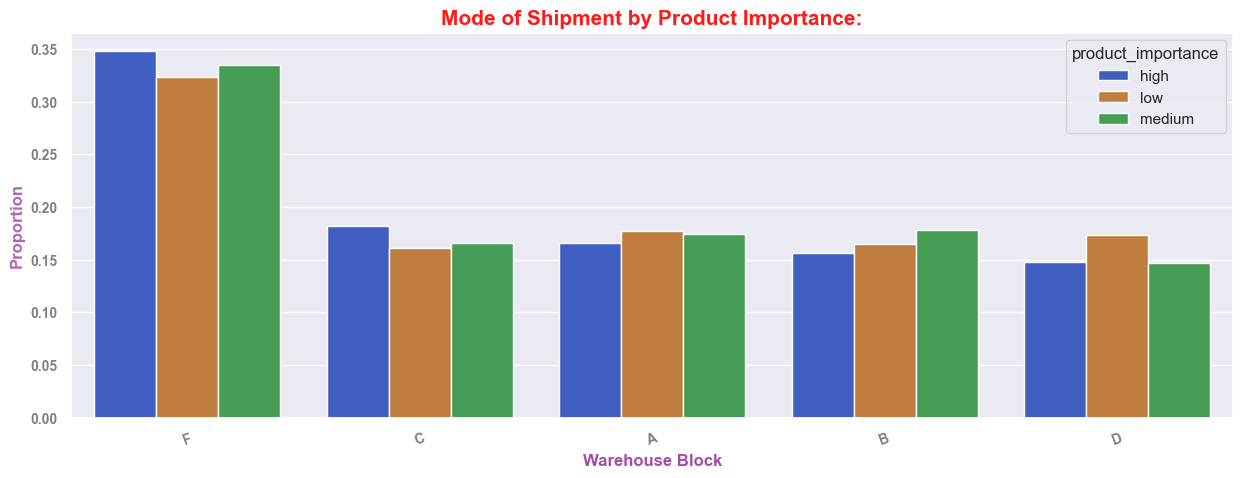

In [48]:
plt.figure(figsize= (15, 5))
sns.set_theme(context= "notebook", style= "darkgrid",)
sns.barplot(data= aa, x= "warehouse_block", y= "count", hue= "product_importance", palette= "bright", saturation= 0.5) 
plt.title("Mode of Shipment by Product Importance:", fontsize= 15, fontweight= "bold", color= "red", alpha= 0.9)
plt.xlabel("Warehouse Block", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.7)
plt.ylabel("Proportion", fontsize= 12, fontweight= "bold", color= "purple", alpha= 0.6)
plt.xticks(rotation= 20, fontsize= 10, fontweight= "bold", color= "gray", alpha= 1.0)
plt.yticks(fontsize= 10, fontweight= "bold", color= "gray")
plt.show()

---
----
-----

# **20. Rating Prediction Model:** 

* **Description:** Build a regression model to predict a customer's rating based on shipment features.

* **How to do it in Python:** Using Scikit-learn, set `Customer_rating` as your target variable (y). Use other relevant columns as features (X). Train a regression model like `LinearRegression` or `RandomForestRegressor`. Analyze the feature importances to see what drives ratings up or down.